In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


# Predicting Freight Cost:

## Objective:
Predicting freight cost for a vendor invoice using quantity and dollars,to improve cost forecasting, budgeting and vendor negtiation.
- Freight is a non-trivial component of landed cost.
- Poor freight estimates distorts margin and inventory planning.
- Automating freight estimation helps procurement teams forecast true cost before invoice arrival.
  


In [4]:
import os
os.getcwd()

'C:\\Users\\dell\\Invoice ML Project\\notebooks'

In [5]:
vendor_df=pd.read_csv('C:\\Users\\dell\\Invoice ML Project\\data\\vendor_invoice.csv')

vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [6]:
# Exploring the dataset furthermore:

vendor_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000


In [10]:
vendor_df.sample(10)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
4037,1485,CASTLE BRANDS CORP.,2024-10-06,12217,2024-09-22,2024-11-15,5530,99141.47,456.05,NaN
4678,17033,SEA BREEZE CELLARS LLC,2024-11-08,12747,2024-10-24,2024-12-13,98,1348.29,6.61,NaN
3136,1655,FABRIZIA SPIRITS LLC,2024-08-01,11266,2024-07-19,2024-09-08,475,6524.53,29.36,NaN
1805,516,BANFI PRODUCTS CORP,2024-05-09,9985,2024-04-28,2024-06-20,6611,50969.70,259.95,NaN
1000,1265,BLACK ROCK SPIRITS LLC,2024-03-15,9163,2024-03-02,2024-04-17,1,14.05,0.07,NaN
5114,9625,WESTERN SPIRITS BEVERAGE CO,2024-12-12,13235,2024-11-25,2025-01-16,1839,9289.23,44.59,NaN
27,9744,FREDERICK WILDMAN & SONS,2024-01-06,8176,2023-12-24,2024-02-12,1222,8610.71,212.93,NaN
3309,287,APPOLO VINEYARDS LLC,2024-08-21,11490,2024-08-04,2024-09-29,12,124.80,0.66,NaN
2339,90011,FORTUNE WINE BROKERS LLC,2024-06-13,10483,2024-06-01,2024-07-27,74,606.57,2.97,NaN
1550,5612,MILTONS DISTRIBUTING CO,2024-04-25,9683,2024-04-06,2024-05-20,12,104.40,0.52,NaN


In [9]:
vendor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   object 
 2   InvoiceDate   5543 non-null   object 
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   object 
 5   PayDate       5543 non-null   object 
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 433.2+ KB


In [8]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


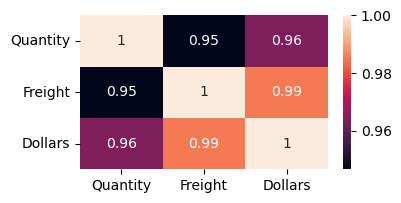

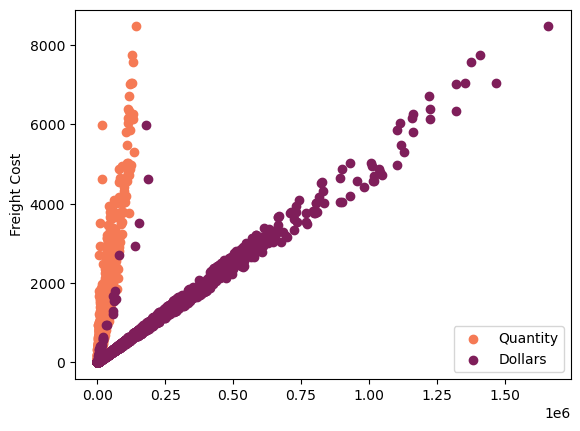

In [13]:
###  Creating a Scatterplot  to show relationship between Quantity,Freight,Dollars:

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Freight','Dollars']].corr(),annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'],color='#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'],color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [15]:
vendor_df['freight_per_unit']=vendor_df['Freight']/vendor_df['Quantity']

In [16]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [17]:
low_quantity

np.float64(83.0)

In [18]:
high_quantity

np.float64(5100.5)

In [19]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_per_unit']

0       0.578333
1       0.571333
2       0.922000
5       0.100000
7       0.881667
          ...   
5523    0.102778
5526    0.088308
5527    0.048611
5528    0.032000
5537    0.053333
Name: freight_per_unit, Length: 1384, dtype: float64

In [20]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity,'freight_per_unit']

3       0.290614
14      0.183063
18      0.359743
22      0.160885
32      0.301962
          ...   
5529    0.036190
5530    0.029653
5532    0.071002
5540    0.094735
5541    0.033117
Name: freight_per_unit, Length: 1386, dtype: float64

In [21]:
# Calculating the freight avg. cost difference for bulk/non bulk orders:

vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [22]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [23]:
X = vendor_df[['Quantity', 'Dollars']]
y= vendor_df['Freight']

In [24]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [27]:
X_train

,Quantity,Dollars
2609,24,264.24
5527,36,342.48
5321,30,572.40
3805,10721,68821.14
1215,80495,604197.73
...,...,...
3772,161,2618.27
5191,6879,74386.98
5226,6,36.96
5390,80,644.00


In [28]:
X_test

,Quantity,Dollars
4564,48,352.95
1616,34773,225706.96
4861,70,634.11
230,104,987.34
2042,4314,31768.74
...,...,...
3388,36,242.16
1321,58,846.99
1322,33887,205379.19
3618,17998,242967.77


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [65]:
model1 = LinearRegression()
model1.fit(X_train,y_train)


model2= DecisionTreeRegressor(random_state =42)
model2.fit( X_train,y_train)


model3= RandomForestRegressor(random_state = 42)
model3.fit(X_train,y_train)


RandomForestRegressor(random_state=42)

In [66]:
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))  # always works
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}%")

In [67]:
evaluate_model(model1, X_test, y_test,'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')


Linear Regression Performance:
MAE: 24.46
RMSE: 124.43
R²: 97.00%

Decision Tree Regression Performance:
MAE: 33.87
RMSE: 182.50
R²: 93.55%

Random Forest Regression Performance:
MAE: 27.65
RMSE: 138.66
R²: 96.28%


In [61]:
model1 = LinearRegression()
model1.fit(X_train,y_train)


model2= DecisionTreeRegressor(max_depth = 4, random_state =42)
model2.fit( X_train,y_train)


model3= RandomForestRegressor(max_depth = 6, random_state = 42)
model3.fit(X_train,y_train)


RandomForestRegressor(max_depth=6, random_state=42)

In [62]:
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))  # always works
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}%")

In [63]:
evaluate_model(model1, X_test, y_test,'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')


Linear Regression Performance:
MAE: 24.46
RMSE: 124.43
R²: 97.00%

Decision Tree Regression Performance:
MAE: 38.12
RMSE: 138.25
R²: 96.30%

Random Forest Regression Performance:
MAE: 25.91
RMSE: 132.71
R²: 96.59%


In [69]:
print(X_test.shape)
print(y_test.shape)

(1109, 2)
(1109,)


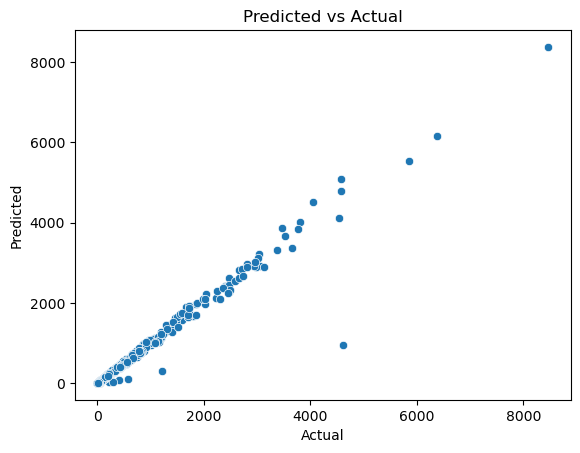

In [76]:
import seaborn as sns

sns.scatterplot(x=y_test, y=model1.predict(X_test))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()